In [271]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler


df = pd.read_parquet("../data/per_state.parquet")

first, we will see how "safe" our states are, we will use k-means to make a clusters of how many incidents, injuries and deaths per capita in states.

In [272]:
df_norm = df.copy()
df_norm

,population,incidents,killed,injured,incidents_per_thousand,killed_per_thousand,injured_per_thousand
state,,,,,,,
District of Columbia,675400,3195,459,1415,4.730530,0.679597,2.095055
Alaska,737498,1349,267,325,1.829158,0.362035,0.440679
Delaware,941252,1685,217,853,1.790169,0.230544,0.906240
Louisiana,4664628,8103,2179,4398,1.737116,0.467133,0.942840
South Carolina,4891938,6939,1610,3084,1.418456,0.329113,0.630425
Illinois,12858913,17556,3409,13514,1.365279,0.265108,1.050944
Mississippi,2988471,3599,1176,1883,1.204295,0.393512,0.630088
Tennessee,6591170,7626,1824,4478,1.157002,0.276734,0.679394
Alabama,4852347,5471,1880,2998,1.127496,0.387441,0.617845


In [273]:
# cols = ["incidents_per_thousand", "killed_per_thousand", "injured_per_thousand"]
# for c in cols:
# df_norm[f"{c}_norm"] = (df_norm[c] - df_norm[c].min()) / (df_norm[c].max() - df_norm[c].min())

In [274]:
X = MinMaxScaler().fit_transform(
    df[["incidents_per_thousand", "killed_per_thousand", "injured_per_thousand"]]
)
df_norm["cluster"] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)

In [275]:
import plotly.express as px

fig = px.scatter_3d(
    df_norm,
    x="incidents_per_thousand",
    y="killed_per_thousand",
    z="injured_per_thousand",
    color="cluster",
    hover_name=df_norm.index,
)
fig.show()

no matter how many clusters we do, DC is always a severe outlier and always a single value in a cluster
on the other hand, the safest state with the lowest incidents, killings and injuries per capita is Hawaii

These clusters can be interpreted as how safe a particular state actually is.

The only question is, how many clusters do we need to have here?

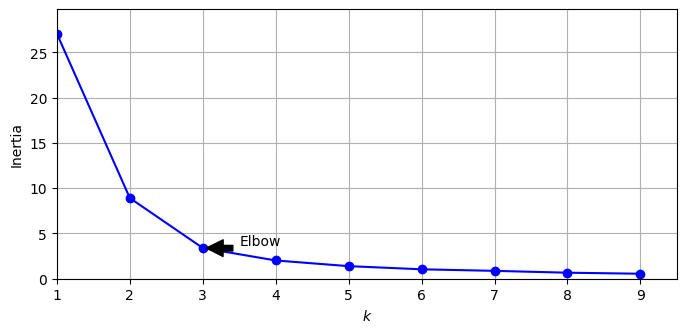

In [276]:
cols = ["incidents_per_thousand", "killed_per_thousand", "injured_per_thousand"]
X = df_norm[cols].values

kmeans_per_k = [
    KMeans(n_clusters=k, n_init=10, random_state=42).fit(X) for k in range(1, 10)
]
inertias = [m.inertia_ for m in kmeans_per_k]

elbow_k = 3

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate(
    "Elbow",
    xy=(elbow_k, inertias[elbow_k - 1]),
    xytext=(elbow_k + 0.5, inertias[elbow_k - 1] + 0.3),
    arrowprops=dict(facecolor="black", shrink=0.1),
)
plt.axis([1, 9.5, 0, max(inertias) * 1.1])
plt.grid()
plt.show()

If we look at the inertia vs k plot we can see that an elbow point may be in point 3, but when we look at the plot with 3 clusters it gives us DC and 2 clusters which are not really that visibly separable. The 4 cluster plot looks better, and it gives us 3 meaningful clusters. We will go with 4

In [277]:
X = MinMaxScaler().fit_transform(
    df[["incidents_per_thousand", "killed_per_thousand", "injured_per_thousand"]]
)
df_norm["cluster4"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

fig = px.scatter_3d(
    df_norm,
    x="incidents_per_thousand",
    y="killed_per_thousand",
    z="injured_per_thousand",
    color="cluster4",
    hover_name=df_norm.index,
)
fig.show()

the clusters here are meaningfull, we can add an attribute named "safety" and assign it to each state
- safe states
- medium safety
- dangerous
- DC (outlier)

In [278]:
df_norm

,population,incidents,killed,injured,incidents_per_thousand,killed_per_thousand,injured_per_thousand,cluster,cluster4
state,,,,,,,,,
District of Columbia,675400,3195,459,1415,4.730530,0.679597,2.095055,2,2
Alaska,737498,1349,267,325,1.829158,0.362035,0.440679,0,0
Delaware,941252,1685,217,853,1.790169,0.230544,0.906240,0,0
Louisiana,4664628,8103,2179,4398,1.737116,0.467133,0.942840,0,0
South Carolina,4891938,6939,1610,3084,1.418456,0.329113,0.630425,0,0
Illinois,12858913,17556,3409,13514,1.365279,0.265108,1.050944,0,0
Mississippi,2988471,3599,1176,1883,1.204295,0.393512,0.630088,0,0
Tennessee,6591170,7626,1824,4478,1.157002,0.276734,0.679394,0,0
Alabama,4852347,5471,1880,2998,1.127496,0.387441,0.617845,0,0


In [279]:
safety_map = {
    0: "dangerous",
    3: "medium safety",
    1: "safe",
    2: "outlier",
}

df_norm["safety"] = df_norm["cluster4"].map(safety_map)

In [280]:
df_norm.groupby("safety")[
    ["incidents_per_thousand", "killed_per_thousand", "injured_per_thousand"]
].mean().round(2).sort_values(by="incidents_per_thousand", ascending=False)

,incidents_per_thousand,killed_per_thousand,injured_per_thousand
safety,,,
outlier,4.73,0.68,2.10
dangerous,1.41,0.34,0.72
medium safety,0.83,0.23,0.40
safe,0.62,0.11,0.20


In [281]:
df["safety"] = df_norm["safety"]

In [282]:
df

,population,incidents,killed,injured,incidents_per_thousand,killed_per_thousand,injured_per_thousand,safety
state,,,,,,,,
District of Columbia,675400,3195,459,1415,4.730530,0.679597,2.095055,outlier
Alaska,737498,1349,267,325,1.829158,0.362035,0.440679,dangerous
Delaware,941252,1685,217,853,1.790169,0.230544,0.906240,dangerous
Louisiana,4664628,8103,2179,4398,1.737116,0.467133,0.942840,dangerous
South Carolina,4891938,6939,1610,3084,1.418456,0.329113,0.630425,dangerous
Illinois,12858913,17556,3409,13514,1.365279,0.265108,1.050944,dangerous
Mississippi,2988471,3599,1176,1883,1.204295,0.393512,0.630088,dangerous
Tennessee,6591170,7626,1824,4478,1.157002,0.276734,0.679394,dangerous
Alabama,4852347,5471,1880,2998,1.127496,0.387441,0.617845,dangerous


In [283]:
def plot_state_map(df, metric, title, color_scale="Reds"):
    fig = px.choropleth(
        df,
        locations="code",
        locationmode="USA-states",
        scope="usa",
        color=metric,
        color_continuous_scale=color_scale,
        hover_name="state",
        # hover_data=["incidents", "killed", "injured", "population"],
        title=title,
    )
    fig.update_layout(title_x=0.5, margin=dict(l=0, r=0, t=60, b=0))
    return fig

In [284]:
state_codes = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
}

df_norm["code"] = df_norm.index.map(state_codes)

In [285]:
df_norm

,population,incidents,killed,injured,incidents_per_thousand,killed_per_thousand,injured_per_thousand,cluster,cluster4,safety,code
state,,,,,,,,,,,
District of Columbia,675400,3195,459,1415,4.730530,0.679597,2.095055,2,2,outlier,DC
Alaska,737498,1349,267,325,1.829158,0.362035,0.440679,0,0,dangerous,AK
Delaware,941252,1685,217,853,1.790169,0.230544,0.906240,0,0,dangerous,DE
Louisiana,4664628,8103,2179,4398,1.737116,0.467133,0.942840,0,0,dangerous,LA
South Carolina,4891938,6939,1610,3084,1.418456,0.329113,0.630425,0,0,dangerous,SC
Illinois,12858913,17556,3409,13514,1.365279,0.265108,1.050944,0,0,dangerous,IL
Mississippi,2988471,3599,1176,1883,1.204295,0.393512,0.630088,0,0,dangerous,MS
Tennessee,6591170,7626,1824,4478,1.157002,0.276734,0.679394,0,0,dangerous,TN
Alabama,4852347,5471,1880,2998,1.127496,0.387441,0.617845,0,0,dangerous,AL


In [286]:
def plot_state_clusters(df, category_col="safety", title="State clusters"):
    df = df.reset_index() if df.index.name == "state" else df
    color_map = {
        "safe": "#2ca02c",
        "medium safety": "#ffbb33",
        "dangerous": "#d62728",
        "outlier": "#7f7f7f",
    }
    fig = px.choropleth(
        df,
        locations="code",
        locationmode="USA-states",
        scope="usa",
        color=category_col,
        color_discrete_map=color_map,
        hover_name="state",
        title=title,
        category_orders={
            category_col: ["safe", "medium safety", "dangerous", "outlier"]
        },
    )
    fig.update_layout(title_x=0.5, margin=dict(l=0, r=0, t=60, b=0))
    return fig

In [287]:
plot_state_clusters(df_norm)

We will also make some regressions and analysis to see how much particular attributes corelate to the statistics about killings, injuries and incidents per 100k people in states,


We will use external datasets.
The first one will be the income of particular states (data from https://nces.ed.gov/programs/digest/d16/tables/dt16_102.30.asp , this is a government site)

In [288]:
df_money = pd.read_csv("../data/state_income_2015.csv")

In [289]:
Median_Income_USA = df_money.loc[df_money["state"] == "United States"][
    "median_household_income_2015"
].values[0]
Median_Income_USA

np.int64(55800)

In [290]:
df = df.merge(
    df_money[["state", "median_household_income_2015"]], on="state", how="left"
)

next, the temperature from each state (data from https://www.currentresults.com/Weather/US/average-annual-state-temperatures.php )

In [291]:
df_temperature = pd.read_csv("../data/state_temperature.csv")
df = df.merge(df_temperature[["state", "avg_temp_c"]], on="state", how="left")
# there is no info about DC, so I just searched it, it is 15 C
df.loc[df["state"] == "District of Columbia", "avg_temp_c"] = 15

next, urbanization data per state. There was no data for 2015, this data is to be found only every 10 years. We have data from 2010 from Iowa University. https://www.icip.iastate.edu/tables/population/urban-pct-states

In [292]:
df_urbanization = pd.read_csv("../data/state_urbanization.csv")
df = df.merge(df_urbanization[["state", "urbanization_2010"]], on="state", how="left")

In 2016 there was an election in the USA. Our data is from that period. We added % of people who voted for Trump and Clinton in that year per state. Data is from wikipedia

In [293]:
df_votes = pd.read_csv("../data/state_election_2016.csv")
df = df.merge(df_votes[["state", "Clinton_votes"]], on="state", how="left")
df = df.merge(df_votes[["state", "Trump_votes"]], on="state", how="left")

now, the median state age. We have already done some plots when it came for particular people. Data is from 2020 from wikipedia

In [294]:
df_age = pd.read_csv("../data/state_median_age.csv")
df = df.merge(df_age[["state", "median_age"]], on="state", how="left")

let's now look at ethnicity https://pmc.ncbi.nlm.nih.gov/articles/PMC5848096/

In [295]:
df_race = pd.read_csv("../data/state_race_2015.csv")
df = df.merge(df_race[["state", "pct_white"]], on="state", how="left")
df = df.merge(df_race[["state", "pct_black"]], on="state", how="left")
df = df.merge(df_race[["state", "pct_hispanic"]], on="state", how="left")
df = df.merge(df_race[["state", "pct_asian"]], on="state", how="left")
df = df.merge(df_race[["state", "pct_native"]], on="state", how="left")
df = df.merge(df_race[["state", "pct_mixed"]], on="state", how="left")

now, unemployment https://www.bls.gov/opub/ted/2016/u-3-and-u-6-unemployment-by-state-2015.htm

In [296]:
df_unemployment = pd.read_csv("../data/state_unemployment_2015.csv")
df = df.merge(df_unemployment[["state", "unemployment"]], on="state", how="left")

now state education

In [297]:
df_education = pd.read_csv("../data/state_education.csv")
df = df.merge(df_education[["state", "pct_bachelors"]], on="state", how="left")

In [299]:
df["unemployment"].isna().sum()

np.int64(0)

In [300]:
df_reg = df.copy()

for our regression analysis, we will throw out DC as it is a severe outlier


In [315]:
df_reg = df_reg[df_reg["state"] != "District of Columbia"]


In [302]:
from sklearn.linear_model import LinearRegression

features = [
    "median_household_income_2015",
    "avg_temp_c",
    "urbanization_2010",
    "Clinton_votes",
    "Trump_votes",
    "median_age",
    "pct_white",
    "pct_black",
    "pct_hispanic",
    "pct_asian",
    "pct_native",
    "pct_mixed",
    "unemployment",
    "pct_bachelors",
]


def vif_sklearn(X):
    vifs = {}
    for col in X.columns:
        y = X[col]
        others = X.drop(columns=col)
        r2 = LinearRegression().fit(others, y).score(others, y)
        vifs[col] = 1 / (1 - r2) if r2 < 1 else float("inf")
    return pd.Series(vifs).sort_values(ascending=False)


print(vif_sklearn(df_reg[features].dropna()).round(2))

pct_white                       579.83
pct_hispanic                    218.69
pct_black                       194.89
pct_asian                       127.13
pct_native                       29.65
Clinton_votes                    26.37
pct_mixed                        22.71
Trump_votes                      18.87
pct_bachelors                     8.41
median_household_income_2015      7.53
avg_temp_c                        6.87
urbanization_2010                 4.73
median_age                        4.10
unemployment                      2.87
dtype: float64


We cannot put every attribute into a linear regression because of multicollinearity, we will have to do regressions separately.

In [303]:
#df_reg.drop(
 #   columns=["Clinton_votes", "pct_white", "pct_asian", "pct_bachelors"], inplace=True
#)

we also have 3 attributes which all have meaning
- deaths
- injuries
- incidents,
we will use pca to make one representative attribute for all 3

In [304]:
from sklearn.decomposition import PCA


cols = ["incidents_per_thousand", "killed_per_thousand", "injured_per_thousand"]

# Standardize first — PCA is scale-sensitive
X = MinMaxScaler().fit_transform(df_reg[cols])

# Fit PCA, keep only the first component
pca = PCA(n_components=1, random_state=42)
df_reg["violence_score"] = pca.fit_transform(X).flatten()

# Sanity checks
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(
    f"Loadings (how each column contributes): {dict(zip(cols, pca.components_[0].round(3)))}"
)

Variance explained by PC1: 85.0%
Loadings (how each column contributes): {'incidents_per_thousand': np.float64(0.546), 'killed_per_thousand': np.float64(0.594), 'injured_per_thousand': np.float64(0.591)}


These pca stats are good for us, the data represent one thing.

In [305]:
df_reg[["state", "violence_score"]].sort_values(by="violence_score", ascending=False)

,state,violence_score
3,Louisiana,1.051216
2,Delaware,0.714875
5,Illinois,0.706994
1,Alaska,0.635164
6,Mississippi,0.582439
4,South Carolina,0.564098
8,Alabama,0.540822
9,Missouri,0.462529
7,Tennessee,0.431906
10,Maryland,0.287192


In [306]:
df_reg["code"] = df_reg["state"].map(state_codes)
df_reg.head()

,state,population,incidents,killed,injured,incidents_per_thousand,killed_per_thousand,injured_per_thousand,safety,median_household_income_2015,...,pct_white,pct_black,pct_hispanic,pct_asian,pct_native,pct_mixed,unemployment,pct_bachelors,violence_score,code
1,Alaska,737498,1349,267,325,1.829158,0.362035,0.440679,dangerous,73400,...,60.0,2.0,7.0,6.0,15.0,8.0,6.7,32.79,0.635164,AK
2,Delaware,941252,1685,217,853,1.790169,0.230544,0.906240,dangerous,61300,...,61.0,22.0,10.0,4.0,0.0,3.0,5.0,35.62,0.714875,DE
3,Louisiana,4664628,8103,2179,4398,1.737116,0.467133,0.942840,dangerous,45700,...,59.0,32.0,5.0,2.0,1.0,2.0,6.2,26.45,1.051216,LA
4,South Carolina,4891938,6939,1610,3084,1.418456,0.329113,0.630425,dangerous,47200,...,64.0,26.0,6.0,2.0,0.0,2.0,5.9,31.53,0.564098,SC
5,Illinois,12858913,17556,3409,13514,1.365279,0.265108,1.050944,dangerous,59600,...,61.0,14.0,18.0,6.0,0.0,2.0,5.9,37.14,0.706994,IL


In [307]:
df_reg["violence_score_normalized"] = MinMaxScaler().fit_transform(
    df_reg[["violence_score"]]
)
df_reg[["state", "violence_score", "violence_score_normalized"]].head()

,state,violence_score,violence_score_normalized
1,Alaska,0.635164,0.745605
2,Delaware,0.714875,0.794344
3,Louisiana,1.051216,1.000000
4,South Carolina,0.564098,0.702152
5,Illinois,0.706994,0.789525


In [308]:
fig = px.choropleth(
    df_reg,
    locations="code",
    locationmode="USA-states",
    scope="usa",
    color="violence_score_normalized",
    color_continuous_scale="Reds",
    hover_name="state",
    hover_data=["violence_score", "incidents", "killed", "injured", "population"],
    title="Violence score by state (PCA-based composite metric, normalized)",
)
fig.update_layout(title_x=0.5, margin=dict(l=0, r=0, t=60, b=0))
fig.show()

In [309]:
data = df_reg.dropna(subset=features + ["violence_score"])
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(data[features])
y = scaler_y.fit_transform(data[["violence_score"]]).ravel()

# Fit
model = LinearRegression().fit(X, y)
print(f"R² = {model.score(X, y):.3f}")
print(f"Intercept = {model.intercept_:.3f}")

# Coefficient table sorted by absolute size
coefs = (
    pd.Series(model.coef_, index=features)
    .to_frame("coefficient")
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .round(4)
)
print("\nFeatures ranked by absolute contribution:")
print(coefs)

R² = 0.740
Intercept = -2.364

Features ranked by absolute contribution:
                              coefficient
pct_white                          2.3204
pct_black                          1.5117
pct_hispanic                       1.0581
pct_asian                          0.7918
pct_native                         0.7872
pct_mixed                          0.5960
pct_bachelors                     -0.5936
median_household_income_2015       0.3675
avg_temp_c                         0.3591
Clinton_votes                      0.2463
unemployment                       0.1982
median_age                        -0.0885
urbanization_2010                  0.0766
Trump_votes                       -0.0747


In [310]:

import statsmodels.api as sm



def univariate_regressions(df, features, target, scale=True, plot=True, ncols=4):
    """
    Fit a separate simple linear regression of `target` on each feature.
    Returns a dataframe of (coefficient, intercept, R², p-value) per feature,
    and optionally shows a grid of scatter plots with regression lines.
    """
    data = df.dropna(subset=features + [target])
    y = data[[target]].values
    if scale:
        y = MinMaxScaler().fit_transform(y)
    y = y.ravel()

    results = []
    fitted = {}  # store scaled x and fit predictions for plotting

    for feat in features:
        x_raw = data[[feat]].values
        x = MinMaxScaler().fit_transform(x_raw) if scale else x_raw
        X = sm.add_constant(x)
        model = sm.OLS(y, X).fit()
        results.append({
            "feature":     feat,
            "coefficient": model.params[1],
            "intercept":   model.params[0],
            "R²":          model.rsquared,
            "p_value":     model.pvalues[1],
        })
        fitted[feat] = (x.ravel(), model.predict(X))

    results_df = (pd.DataFrame(results)
                  .sort_values("R²", ascending=False)
                  .reset_index(drop=True))
    results_df["sig"] = results_df["p_value"].apply(
        lambda p: "significant" if p < 0.01 else "less significant" if p < 0.05 else ""
    )

    if plot:
        n = len(features)
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
        axes = axes.flatten()
        for ax, row in zip(axes, results_df.itertuples()):
            x_vals, y_pred = fitted[row.feature]
            order = np.argsort(x_vals)
            ax.scatter(x_vals, y, alpha=0.6, s=30, edgecolors="k", linewidths=0.3)
            ax.plot(x_vals[order], y_pred[order], color="red", linewidth=2)
            ax.set_title(f"{row.feature}\nR² = {row._4:.2f},  p = {row.p_value:.4f} {row.sig}",
                         fontsize=10)
            ax.set_xlabel(row.feature, fontsize=8)
            ax.set_ylabel(target, fontsize=8)
            ax.grid(alpha=0.3)
        # hide any unused axes
        for ax in axes[n:]:
            ax.set_visible(False)
        fig.tight_layout()
        plt.show()

    return results_df.round(4)


# --- usage ---


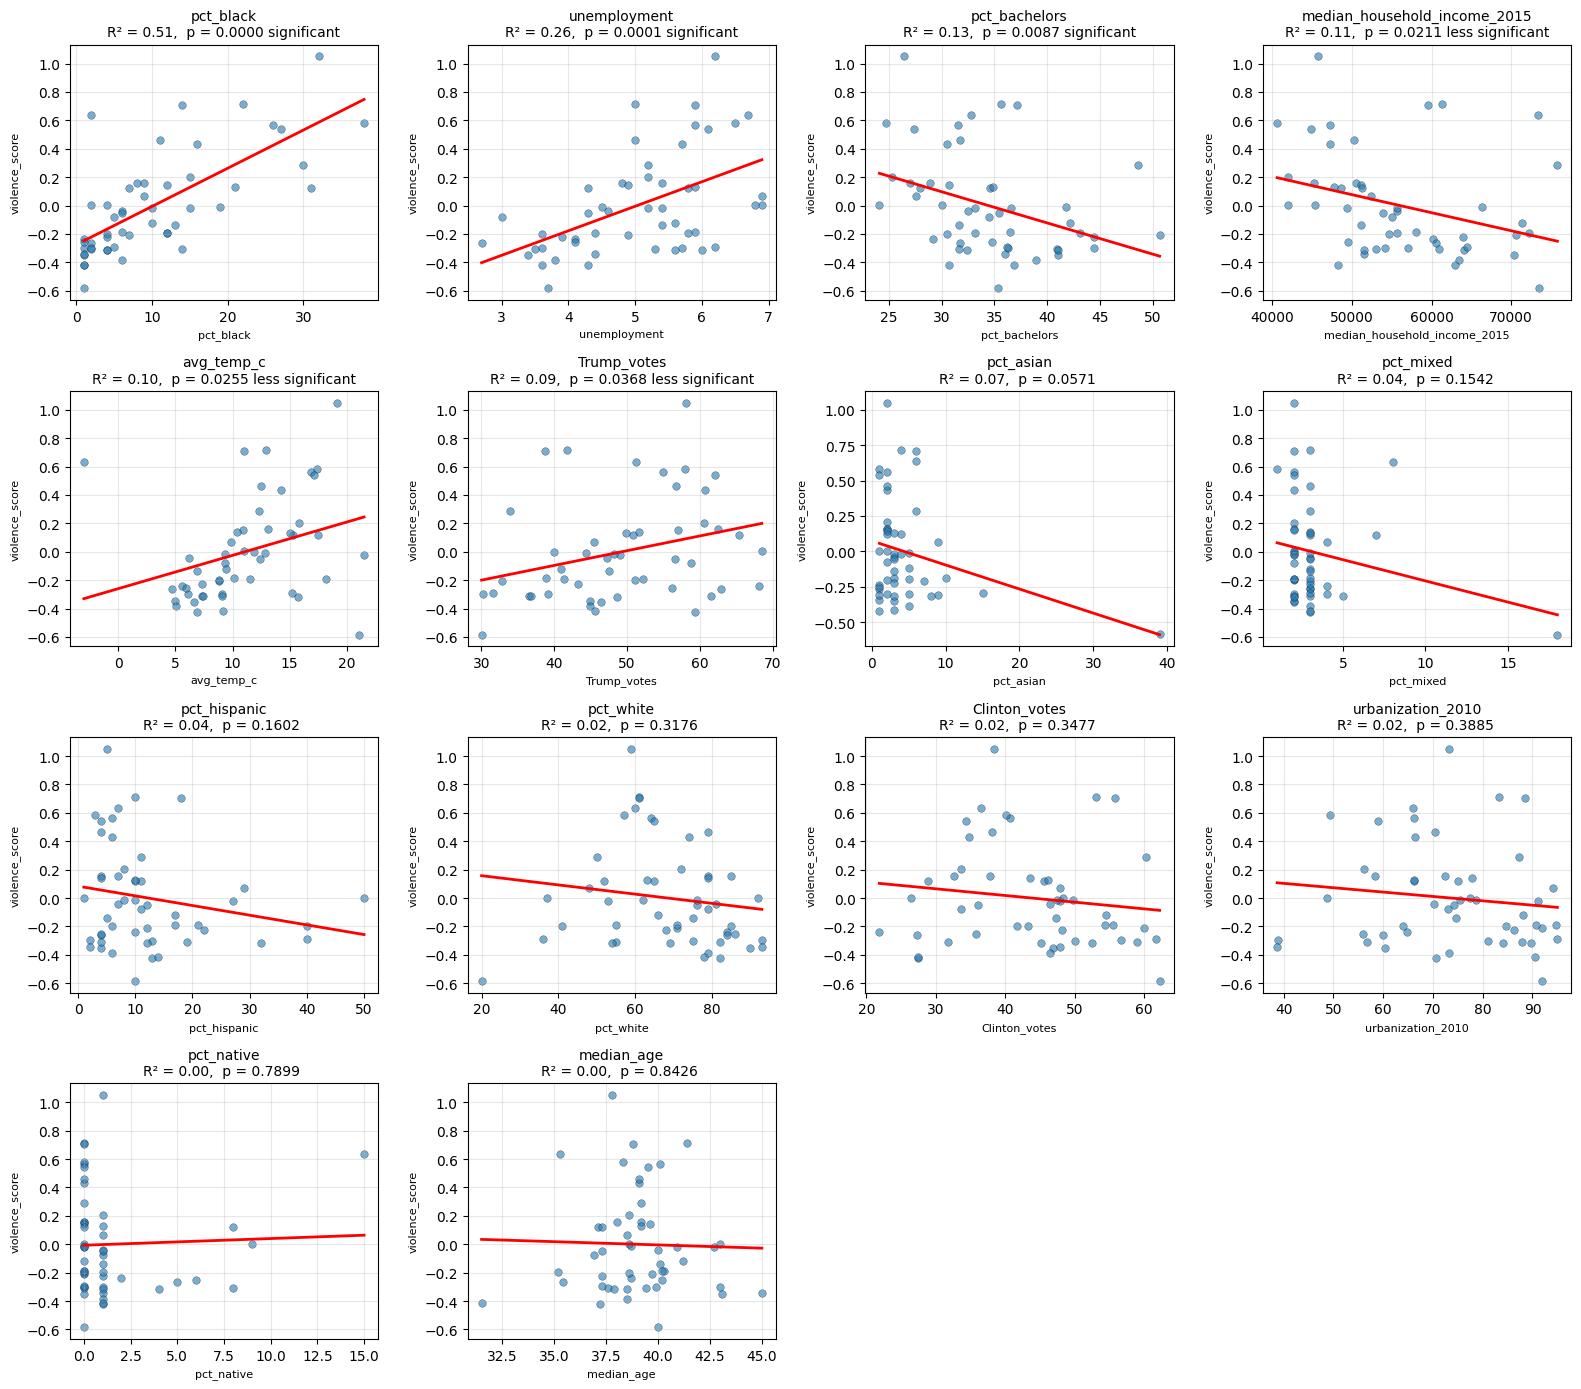

                         feature  coefficient  intercept      R²  p_value  \
0                      pct_black       0.0269    -0.2757  0.5066   0.0000   
1                   unemployment       0.1727    -0.8689  0.2646   0.0001   
2                  pct_bachelors      -0.0220     0.7581  0.1349   0.0087   
3   median_household_income_2015      -0.0000     0.7118  0.1060   0.0211   
4                     avg_temp_c       0.0235    -0.2601  0.0997   0.0255   
5                    Trump_votes       0.0104    -0.5116  0.0877   0.0368   
6                      pct_asian      -0.0170     0.0737  0.0734   0.0571   
7                      pct_mixed      -0.0298     0.0931  0.0418   0.1542   
8                   pct_hispanic      -0.0068     0.0835  0.0407   0.1602   
9                      pct_white      -0.0032     0.2221  0.0208   0.3176   
10                 Clinton_votes      -0.0047     0.2062  0.0184   0.3477   
11             urbanization_2010      -0.0031     0.2263  0.0155   0.3885   

In [311]:
features2 = [
    "median_household_income_2015",
    "avg_temp_c",
    "urbanization_2010",
    "Clinton_votes",
    "Trump_votes",
    "median_age",
    "pct_white",
    "pct_black",
    "pct_hispanic",
    "pct_asian",
    "pct_native",
    "pct_mixed",
    "unemployment",
    "pct_bachelors",
]


results = univariate_regressions(df_reg, features2, "violence_score", scale=False)
print(results)

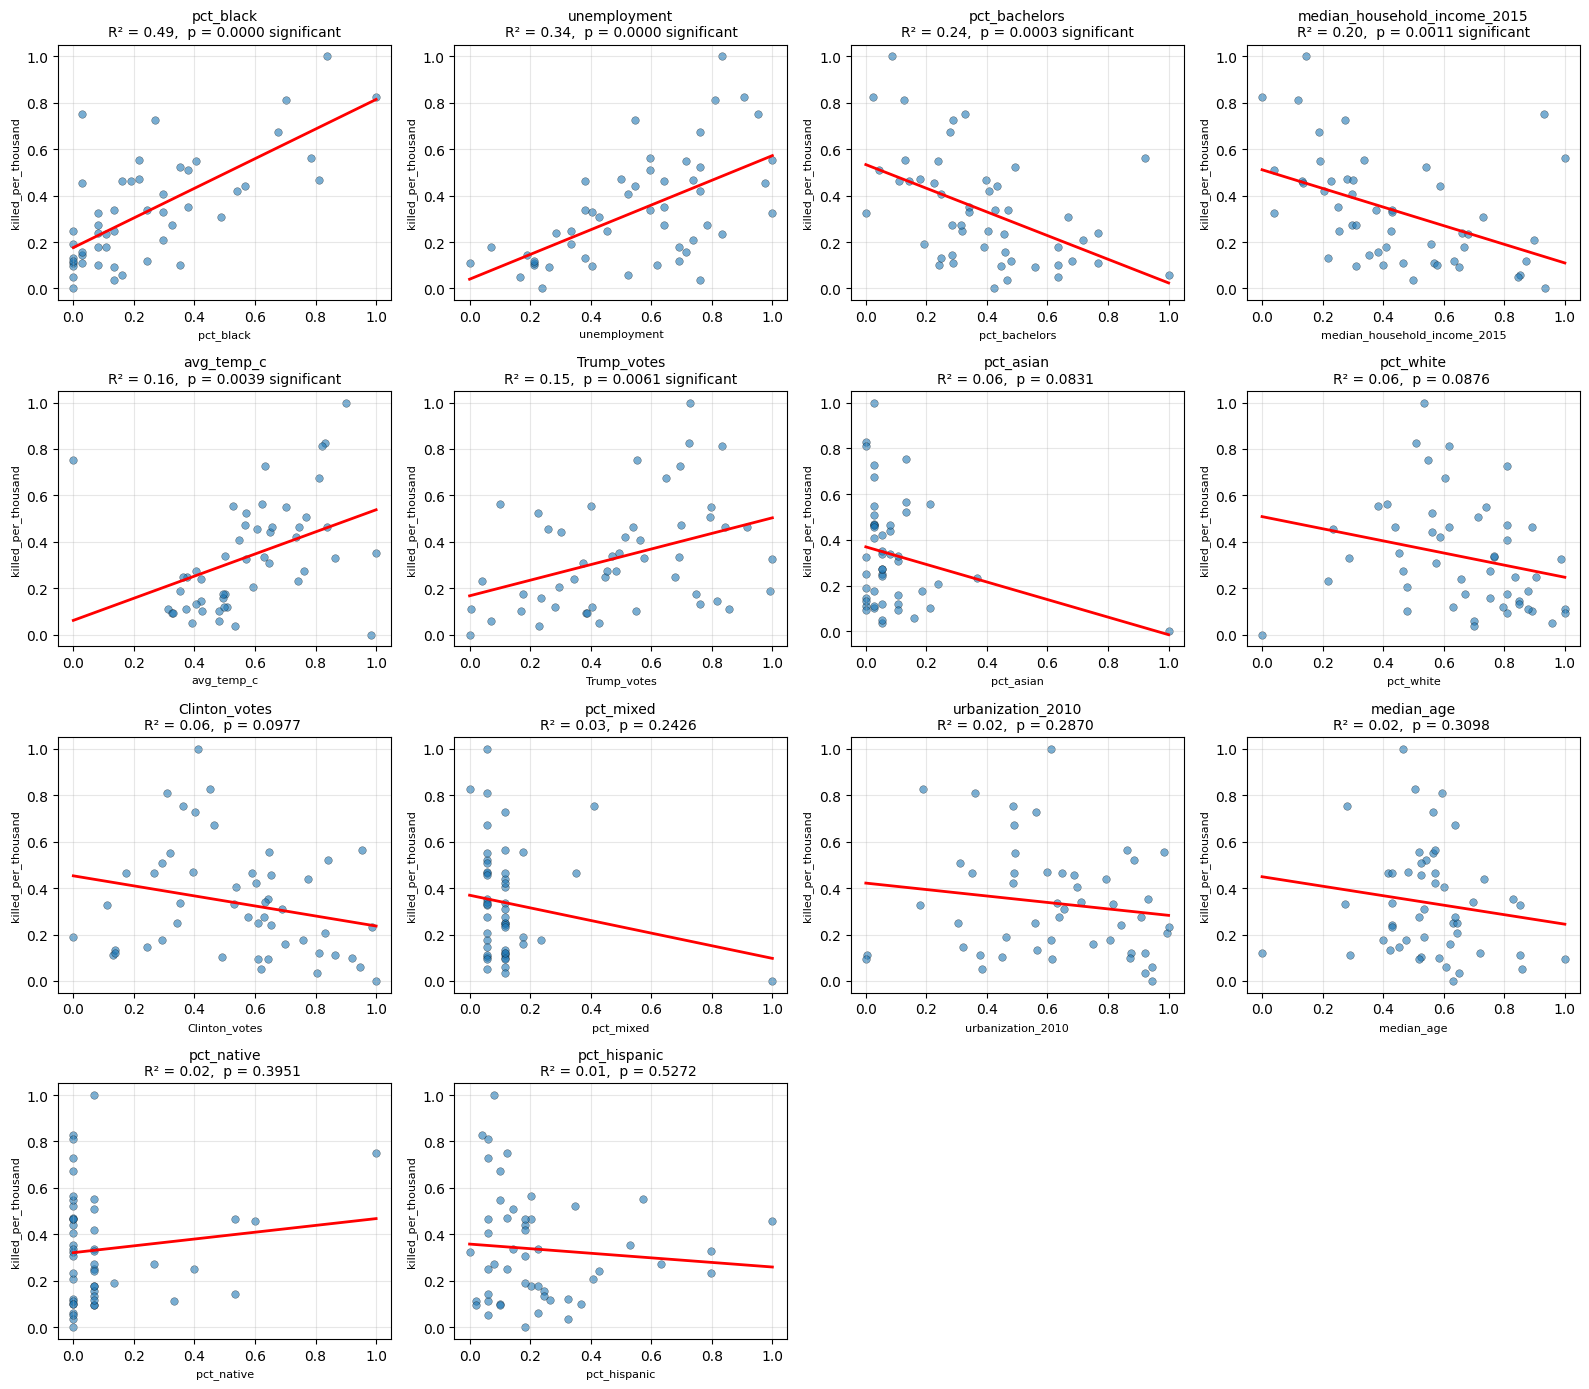

                         feature  coefficient  intercept      R²  p_value  \
0                      pct_black       0.6381     0.1760  0.4899   0.0000   
1                   unemployment       0.5324     0.0398  0.3359   0.0000   
2                  pct_bachelors      -0.5097     0.5335  0.2425   0.0003   
3   median_household_income_2015      -0.4015     0.5113  0.2012   0.0011   
4                     avg_temp_c       0.4764     0.0617  0.1610   0.0039   
5                    Trump_votes       0.3360     0.1675  0.1462   0.0061   
6                      pct_asian      -0.3840     0.3691  0.0613   0.0831   
7                      pct_white      -0.2612     0.5087  0.0596   0.0876   
8                  Clinton_votes      -0.2162     0.4528  0.0561   0.0977   
9                      pct_mixed      -0.2720     0.3693  0.0283   0.2426   
10             urbanization_2010      -0.1390     0.4215  0.0236   0.2870   
11                    median_age      -0.2044     0.4490  0.0215   0.3098   

In [312]:
results_murder = univariate_regressions(df_reg, features2, "killed_per_thousand")
print(results_murder)

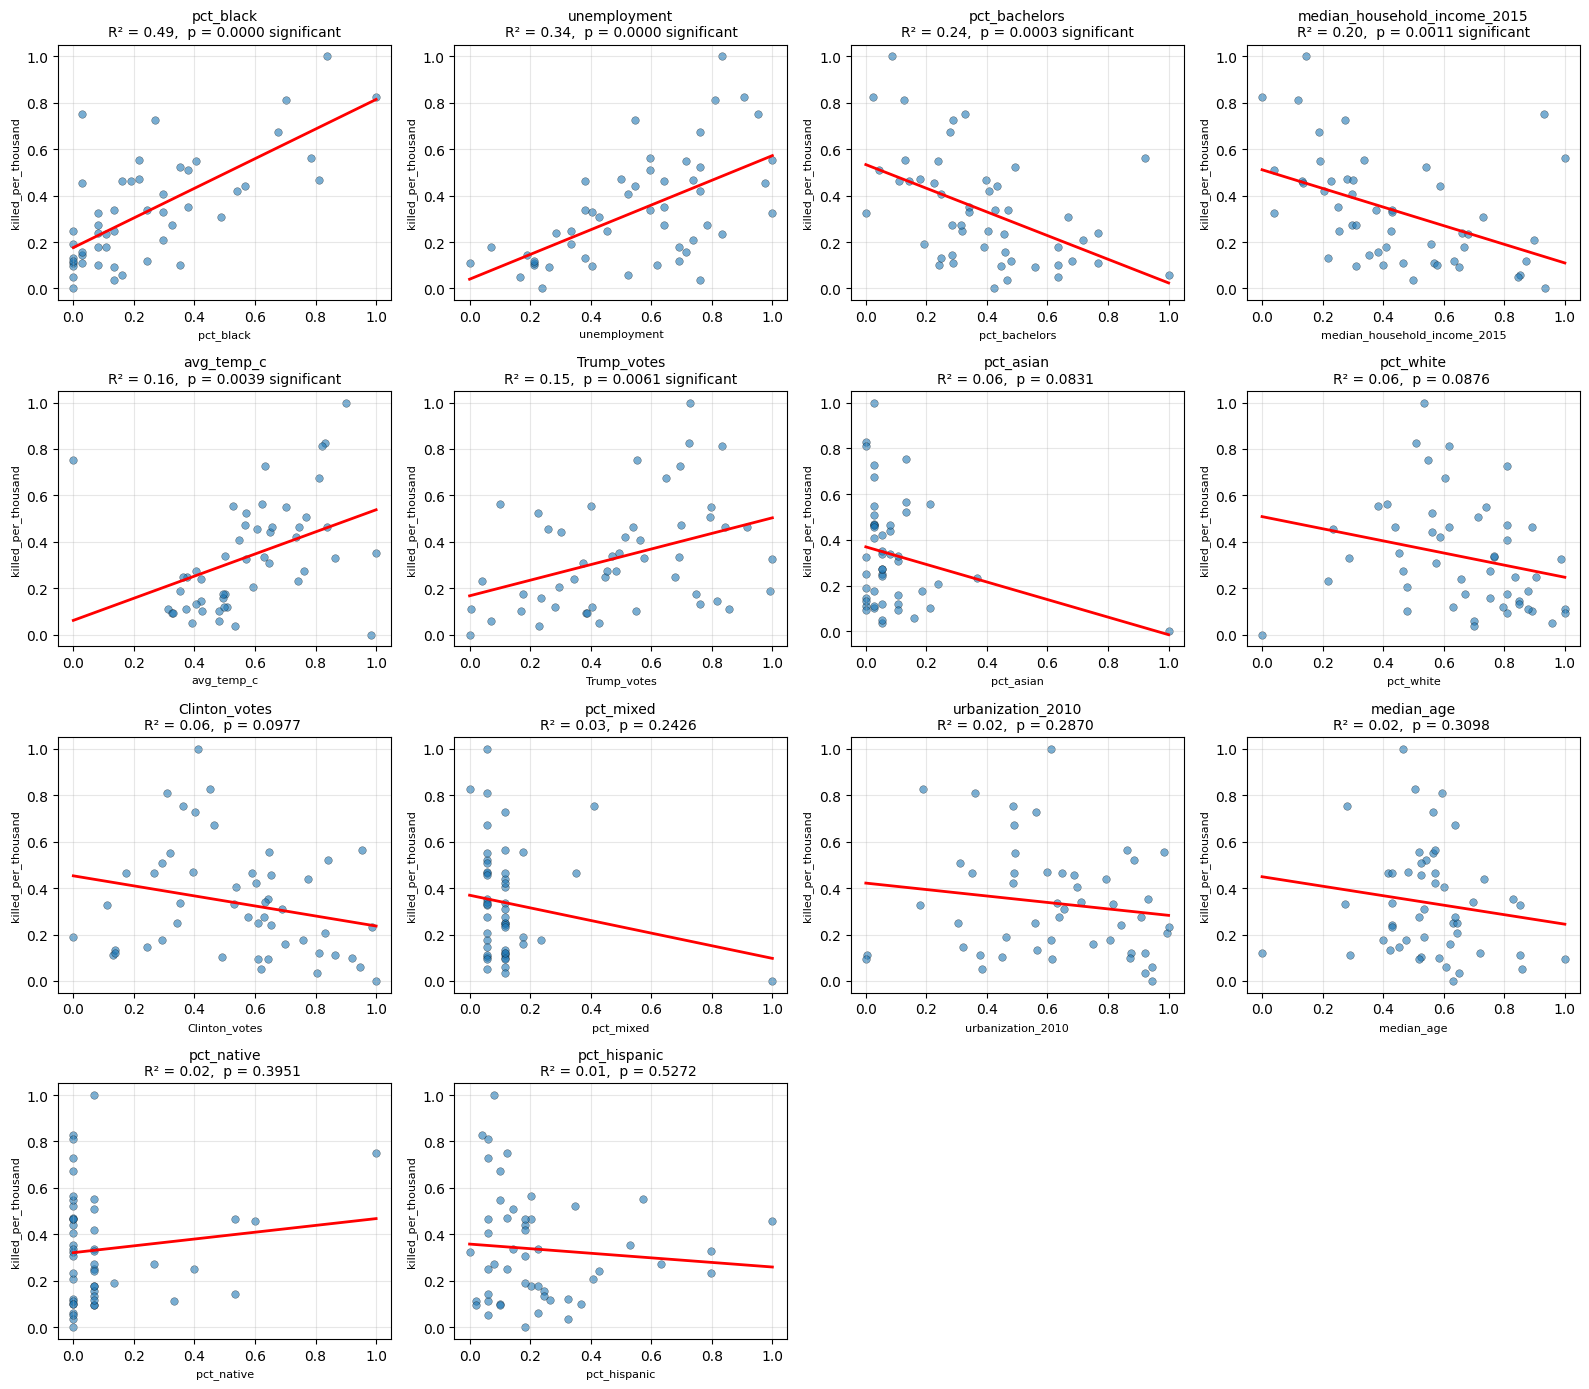

                         feature  coefficient  intercept      R²  p_value  \
0                      pct_black       0.6381     0.1760  0.4899   0.0000   
1                   unemployment       0.5324     0.0398  0.3359   0.0000   
2                  pct_bachelors      -0.5097     0.5335  0.2425   0.0003   
3   median_household_income_2015      -0.4015     0.5113  0.2012   0.0011   
4                     avg_temp_c       0.4764     0.0617  0.1610   0.0039   
5                    Trump_votes       0.3360     0.1675  0.1462   0.0061   
6                      pct_asian      -0.3840     0.3691  0.0613   0.0831   
7                      pct_white      -0.2612     0.5087  0.0596   0.0876   
8                  Clinton_votes      -0.2162     0.4528  0.0561   0.0977   
9                      pct_mixed      -0.2720     0.3693  0.0283   0.2426   
10             urbanization_2010      -0.1390     0.4215  0.0236   0.2870   
11                    median_age      -0.2044     0.4490  0.0215   0.3098   

In [313]:
results_injured = univariate_regressions(df_reg, features2, "killed_per_thousand")
print(results_injured)

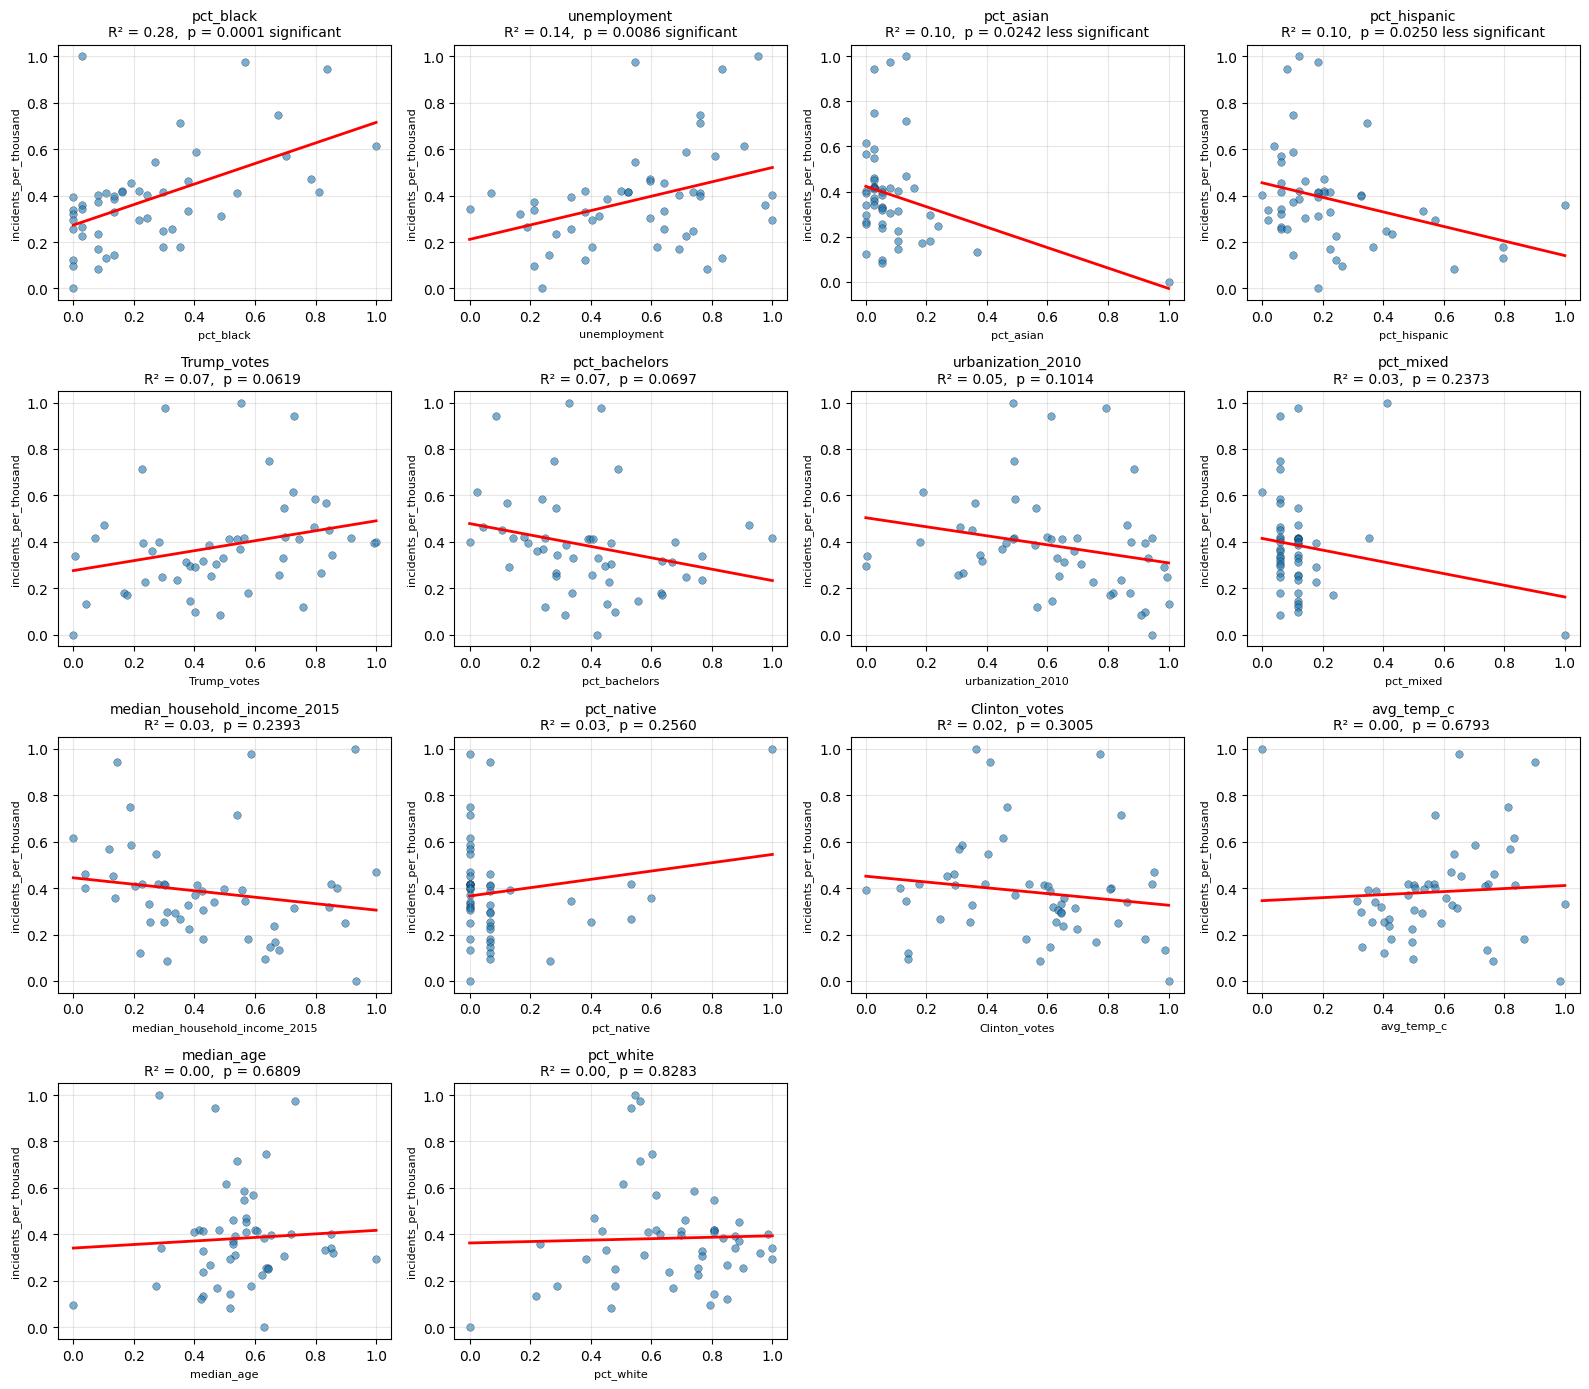

                         feature  coefficient  intercept      R²  p_value  \
0                      pct_black       0.4423     0.2728  0.2797   0.0001   
1                   unemployment       0.3096     0.2114  0.1351   0.0086   
2                      pct_asian      -0.4532     0.4231  0.1014   0.0242   
3                   pct_hispanic      -0.3136     0.4552  0.1004   0.0250   
4                    Trump_votes       0.2144     0.2761  0.0707   0.0619   
5                  pct_bachelors      -0.2456     0.4787  0.0669   0.0697   
6              urbanization_2010      -0.1945     0.5038  0.0549   0.1014   
7                      pct_mixed      -0.2523     0.4147  0.0290   0.2373   
8   median_household_income_2015      -0.1392     0.4442  0.0287   0.2393   
9                     pct_native       0.1791     0.3658  0.0268   0.2560   
10                 Clinton_votes      -0.1250     0.4512  0.0223   0.3005   
11                    avg_temp_c       0.0653     0.3458  0.0036   0.6793   

In [314]:
results_incidents = univariate_regressions(df_reg, features2, "incidents_per_thousand")
print(results_incidents)

We chose p value = 0.01 because this is a controversial topic and we want to be careful here. Regressions differ here. Percent of asian population is not really that valuable because of Hawaii, which is an outlier here. It turns out that unemployment is a big factor when it comes to how many gun violence there is in particular states.